In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
import networkx as nx

# Загрузка данных
all_data = pd.read_csv('r.csv')
print(all_data)

          0       1       2       3       4       5       6
0     Bread    Wine    Eggs    Meat  Cheese  Pencil  Diaper
1     Bread  Cheese    Meat  Diaper    Wine    Milk  Pencil
2    Cheese    Meat    Eggs    Milk    Wine     NaN     NaN
3    Cheese    Meat    Eggs    Milk    Wine     NaN     NaN
4      Meat  Pencil    Wine     NaN     NaN     NaN     NaN
..      ...     ...     ...     ...     ...     ...     ...
310   Bread    Eggs  Cheese     NaN     NaN     NaN     NaN
311    Meat    Milk  Pencil     NaN     NaN     NaN     NaN
312   Bread  Cheese    Eggs    Meat  Pencil  Diaper    Wine
313    Meat  Cheese     NaN     NaN     NaN     NaN     NaN
314    Eggs    Wine   Bagel   Bread    Meat     NaN     NaN

[315 rows x 7 columns]


ВАРИАНТ №4 из предложенных

Данные представляют покупательские наборы (корзины). Все транзакции, совершенны в период с 01.12.2010 по 09.12.2011 для зарегистрированной в Великобритании интернет-торговли, не являющейся магазином.Многие клиенты компании являются оптовиками.

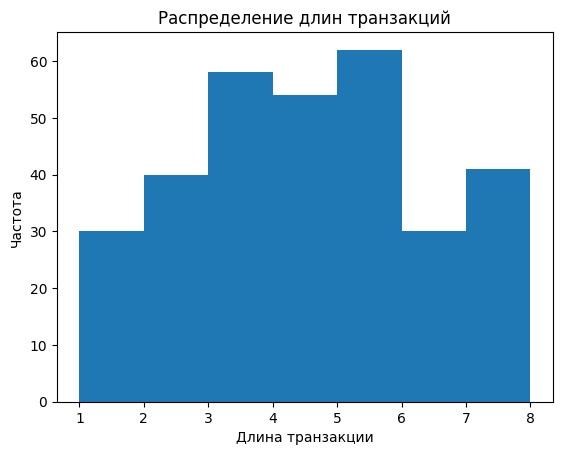

{'Bagel', 'Wine', 'Meat', 'Milk', 'Bread', 'Diaper', 'Eggs', 'Cheese', 'Pencil'}


In [40]:
# Анализ транзакций
transaction_lengths = all_data.notnull().sum(axis=1)
plt.hist(transaction_lengths, bins=range(1, max(transaction_lengths) + 2))
plt.xlabel('Длина транзакции')
plt.ylabel('Частота')
plt.title('Распределение длин транзакций')
plt.show()

# Очистка данных
#Уберём срез raw[1:]
np_data = all_data.to_numpy()
np_data = [[elem for elem in row if isinstance(elem, str)] for row in np_data]

# Список уникальных товаров
unique_items = set()
for row in np_data:
    for elem in row:
        unique_items.add(elem)
print(unique_items)

Проведем анализ выборки. На графике изображено распределение количества продуктов в покупательской корзине - оно согласуется с нормальным распределением.
Чаще всего длина транзакции составляет 3-6.
 Выведем продукты с помощью set(), чтобы исключить повторяющиеся элементы.

In [41]:
te = TransactionEncoder()
te_ary = te.fit(np_data).transform(np_data)
data = pd.DataFrame(te_ary, columns=te.columns_)

Применяемые алгоритмы (Apriori,FPGrowth) принимают на вход бинарную матрицу, где столбцы - товары, строки - транзакции. 
Соответствующие элементы равны 1, если товары входят в транзакцию, иначе 0.
Алгоритм Apriori является более трудоемким, так как подразумевает полный перебор вариантов с отсечением, поэтому на практике с реальными БД применяется второй алгоритм.

In [42]:
#Алгоритм Apriori
df1 = apriori(data, min_support=0.15, use_colnames = True)
print(df1)
rules = association_rules(df1, metric = "confidence", min_threshold = 0.4)
print(rules)

top6_lift = rules.sort_values(by='lift', ascending=False).head(6)
print("\nТоп-6 правил по значению лифта:")
print(top6_lift)

min6_lift = rules.sort_values(by='lift', ascending=True).head(6)
print("\nАнти-топ-6 правил по значению лифта:")
print(min6_lift)

     support                    itemsets
0   0.425397                     (Bagel)
1   0.504762                     (Bread)
2   0.501587                    (Cheese)
3   0.406349                    (Diaper)
4   0.438095                      (Eggs)
5   0.476190                      (Meat)
6   0.501587                      (Milk)
7   0.361905                    (Pencil)
8   0.438095                      (Wine)
9   0.279365              (Bread, Bagel)
10  0.193651             (Cheese, Bagel)
11  0.184127             (Diaper, Bagel)
12  0.152381               (Eggs, Bagel)
13  0.190476               (Meat, Bagel)
14  0.225397               (Milk, Bagel)
15  0.158730             (Bagel, Pencil)
16  0.171429               (Wine, Bagel)
17  0.238095             (Bread, Cheese)
18  0.231746             (Bread, Diaper)
19  0.187302               (Bread, Eggs)
20  0.206349               (Bread, Meat)
21  0.279365               (Bread, Milk)
22  0.200000             (Bread, Pencil)
23  0.244444    

Применили метод Apriori, задав минимальный уровень поддержки в 15%, в соответствии с вариантом. Таким образом формируется список продуктов(и их комбинаций), встречающиеся хотя бы в 15% транзакций. Получено 54 результатов. Далее используем функцию association_rules() с метрикой confidence(A => B) = support(A, B)/support(A), которая берет только те ассоциативные правила, где вероятность встретить продукт B в транзакции, при условии наличия A, равняется 40%. Важен и показатель lift(A, B) = confidencde(A => B)/support(B), который показывает, насколько сильнее правило A => B случайной связи A и B. Будем относить правила с показателем lift <= 1(примерно 1) к тривиальным, полезные - наоборот.

Проанализируем результаты. К наиболее полезным правилам можно отнести сочетания:
(Meat, Milk) - (Eggs, Cheese), где lift = 2.089; если (Meat, Milk) на 1м месте в паре, то confidence = 0.62, иначе confidence = 0.51.
(Eggs, Milk) - (Meat, Cheese), где lift = 1.925; если (Eggs, Milk) на 1м месте в паре, то confidence = 0.62, иначе confidence = 0.47.
(Cheese, Milk) - (Meat, Eggs), где lift = 1.875; если (Cheese, Milk) на 1м месте в паре, то confidence = 0.50, иначе confidence = 0.57.

К наиболее тривиальным правилам:
(Eggs) - (Bread), где lift = 0.847(при покупки одного товара, другой покупают реже), confidence = 0.43
(Bread) - (Meat), где lift = 0.858; если (Bread) на 1м месте в паре, то confidence = 0.41, иначе confidence = 0.43.
(Bagel) - (Cheese), где lift = 0.907, confidence = 0.46

Изменим параметры алгоритма. Зададим поддержку в 23%, достоверность - 45%

In [43]:
df1 = apriori(data, min_support=0.23, use_colnames = True)
print(df1)
rules = association_rules(df1, metric = "confidence", min_threshold = 0.45)
print(rules)

top6_lift = rules.sort_values(by='lift', ascending=False).head(6)
print("\nТоп-6 правил по значению лифта:")
print(top6_lift)

min6_lift = rules.sort_values(by='lift', ascending=True).head(6)
print("\nАнти-топ-6 правил по значению лифта:")
print(min6_lift)

     support         itemsets
0   0.425397          (Bagel)
1   0.504762          (Bread)
2   0.501587         (Cheese)
3   0.406349         (Diaper)
4   0.438095           (Eggs)
5   0.476190           (Meat)
6   0.501587           (Milk)
7   0.361905         (Pencil)
8   0.438095           (Wine)
9   0.279365   (Bread, Bagel)
10  0.238095  (Bread, Cheese)
11  0.231746  (Bread, Diaper)
12  0.279365    (Bread, Milk)
13  0.244444    (Bread, Wine)
14  0.298413   (Eggs, Cheese)
15  0.323810   (Meat, Cheese)
16  0.304762   (Milk, Cheese)
17  0.269841   (Wine, Cheese)
18  0.234921   (Wine, Diaper)
19  0.266667     (Eggs, Meat)
20  0.244444     (Eggs, Milk)
21  0.241270     (Wine, Eggs)
22  0.244444     (Meat, Milk)
23  0.250794     (Wine, Meat)
   antecedents consequents  antecedent support  consequent support   support  \
0      (Bread)     (Bagel)            0.504762            0.425397  0.279365   
1      (Bagel)     (Bread)            0.425397            0.504762  0.279365   
2      (Br

Количество выбранных продуктов уменьшилось более, чем  2 раза (с 54 до 24). 

В новом наборе данных прежние полезные правила (например, (Meat, Milk) → (Eggs, Cheese)) не обнаружены из-за повышения минимального порога поддержки.
Однако их ключевые компонентные связи (особенно между Cheese, Meat, Eggs) сохраняются, демонстрируя устойчивые взаимосвязи товаров с коэффициентом лифта около 1.35.
Это говорит о стабильности продуктовых зависимостей внутри группы «основные продукты питания». Из тривиальных правил не осталось ни одного, т.к. достоверность увеличена.

In [68]:
df1 = fpgrowth(data, min_support=0.23, use_colnames = True)
print(df1)
rules = association_rules(df1, metric = "confidence", min_threshold = 0.45)
print(rules)

top6_lift = rules.sort_values(by='lift', ascending=False).head(6)
print("\nТоп-6 правил по значению лифта:")
print(top6_lift)

min6_lift = rules.sort_values(by='lift', ascending=True).head(6)
print("\nАнти-топ-6 правил по значению лифта:")
print(min6_lift)

     support         itemsets
0   0.504762          (Bread)
1   0.501587         (Cheese)
2   0.476190           (Meat)
3   0.438095           (Wine)
4   0.438095           (Eggs)
5   0.406349         (Diaper)
6   0.361905         (Pencil)
7   0.501587           (Milk)
8   0.425397          (Bagel)
9   0.238095  (Bread, Cheese)
10  0.323810   (Meat, Cheese)
11  0.244444     (Meat, Milk)
12  0.269841   (Wine, Cheese)
13  0.250794     (Wine, Meat)
14  0.244444    (Bread, Wine)
15  0.298413   (Eggs, Cheese)
16  0.266667     (Eggs, Meat)
17  0.241270     (Wine, Eggs)
18  0.244444     (Eggs, Milk)
19  0.234921   (Wine, Diaper)
20  0.231746  (Bread, Diaper)
21  0.304762   (Milk, Cheese)
22  0.279365    (Bread, Milk)
23  0.279365   (Bread, Bagel)
   antecedents consequents  antecedent support  consequent support   support  \
0      (Bread)    (Cheese)            0.504762            0.501587  0.238095   
1     (Cheese)     (Bread)            0.501587            0.504762  0.238095   
2       (M

Отличий между данными, полученными алгоритмами Apriori и FPG - не наблюдается. Видим полное совпдание. 

In [45]:
supports = []
for i in range(0, len(df1['support'])):
    set_len = len(df1['itemsets'][i])
    cur_sup = df1['support'][i]
    if set_len > len(supports):
        supports.append(cur_sup)
    elif supports[set_len - 1] > cur_sup:
        supports[set_len - 1] = cur_sup
print(supports)
print(len(supports))

[np.float64(0.3619047619047619), np.float64(0.1523809523809524), np.float64(0.1619047619047619), np.float64(0.1523809523809524)]
4


Здесь мы вывели минимальный уровень поддержки для составления правил из 1,2,3 и 4 продуктов.

     support      itemsets
0   0.504762         Bread
1   0.501587        Cheese
7   0.501587          Milk
2   0.476190          Meat
3   0.438095          Wine
4   0.438095          Eggs
8   0.425397         Bagel
5   0.406349        Diaper
6   0.361905        Pencil
10  0.323810  Meat, Cheese


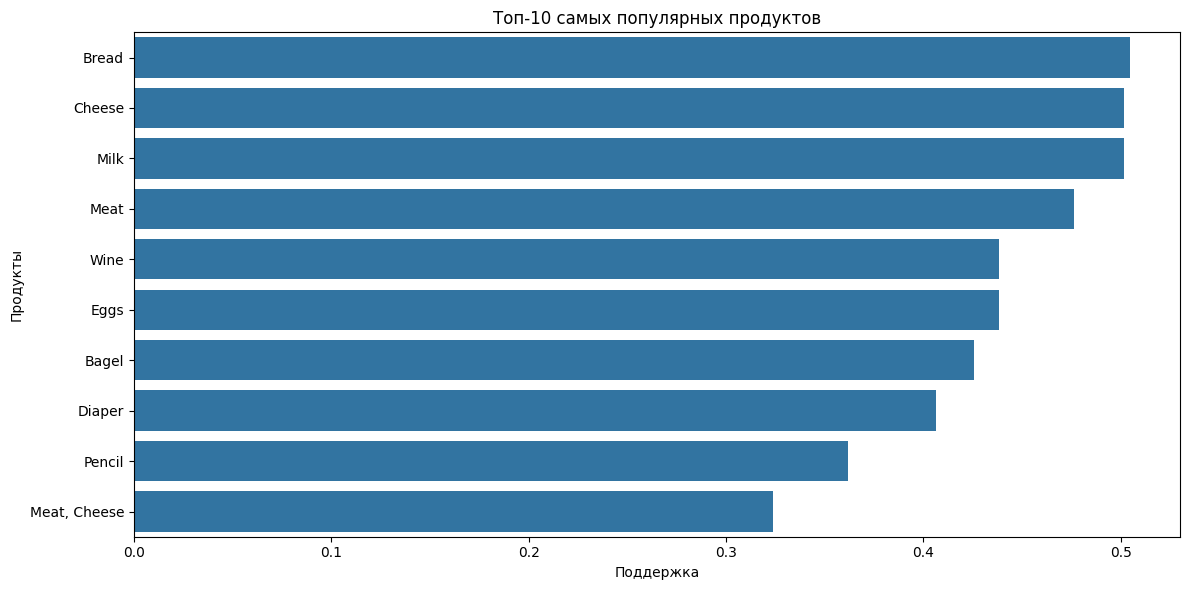

In [69]:
#Поддержка
df1['itemsets'] = df1['itemsets'].apply(lambda x: ', '.join(list(x)))
top_products = df1.sort_values(by='support', ascending=False).head(10)
print(top_products)
plt.figure(figsize=(12, 6))
sns.barplot(x='support', y='itemsets', data=top_products)
plt.title('Топ-10 самых популярных продуктов')
plt.xlabel('Поддержка')
plt.ylabel('Продукты')
plt.tight_layout()
plt.show()

Теперь выведем отсортированные продукты по поддержке. Видно, что чаще всего встречается: Хлеб, Сыр, Молоко, Мясо и т.д.

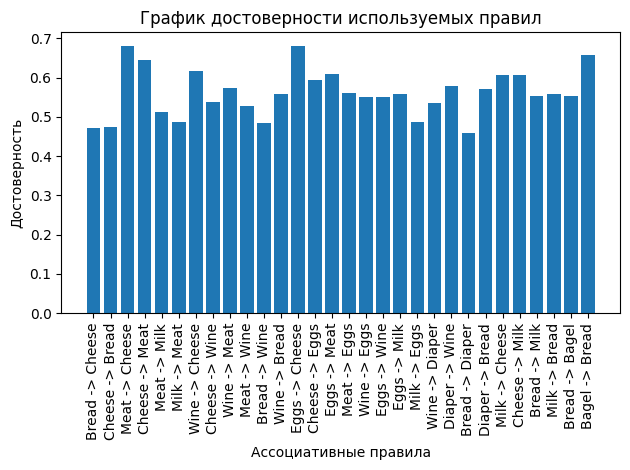

In [70]:

rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))
# График достоверности используемых правил
products_1 = rules["antecedents"].tolist()
products_2 = rules["consequents"].tolist()
confidence = rules["confidence"].tolist()
rules_labels = [f"{product1} -> {product2}" for product1, product2 in zip(products_1, products_2)]

plt.bar(rules_labels, confidence)
plt.xlabel("Ассоциативные правила")
plt.ylabel("Достоверность")
plt.title("График достоверности используемых правил")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

График, отображающий достоверности, найденные при поиске ассоциативных правил.
Видим, что наибольшими достоверностями обладают правила Мясо-> Сыр, Яйца->Сыр, Тесто->Хлеб

C:\Users\manui\AppData\Local\Temp\ipykernel_28616\3501180841.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


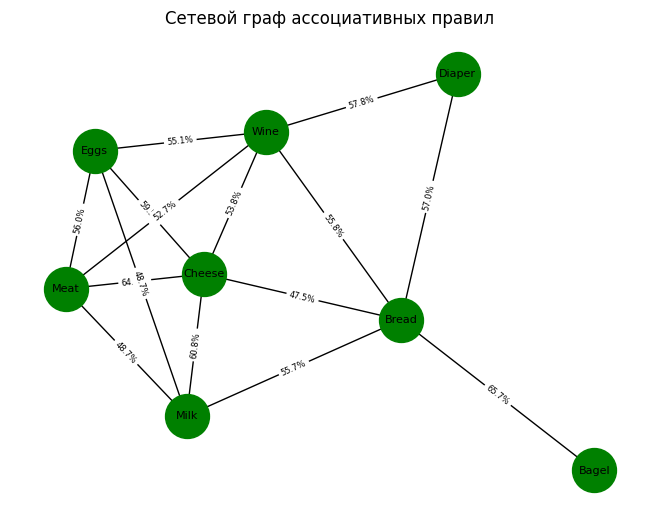

In [71]:
G = nx.Graph()
for product in rules["antecedents"]:
    G.add_node(product)
for product in rules["consequents"]:
    G.add_node(product)
for index, row in rules.iterrows():
    G.add_edge(row['antecedents'], row['consequents'], weight=row['confidence'])
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=1000, node_color='green', font_size=8)
edge_labels = {k: f"{v*100:.1f}%" for k, v in nx.get_edge_attributes(G, 'weight').items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
plt.title('Сетевой граф ассоциативных правил')
plt.tight_layout()
plt.show()

Узлами являются товары, дуги отражают достоверность. Например, если мы приобрели Молоко, то с вероятностью 60.8% мы приобретем Сыр.
Граф наглядно показывает связи между основными товарами покупательских корзин.

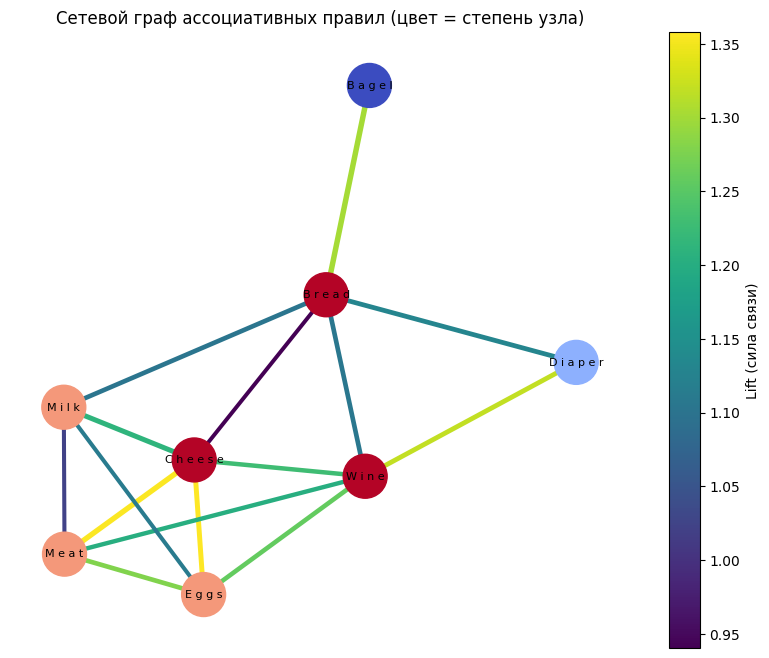

In [75]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.5, iterations=50)

degree = dict(G.degree())
node_colors = [degree[n] for n in G.nodes()]
edge_colors = [d['lift'] for (_, _, d) in G.edges(data=True)]

nodes = nx.draw_networkx_nodes(
    G, pos, node_color=node_colors, cmap=plt.cm.coolwarm, node_size=1000
)
edges = nx.draw_networkx_edges(
    G, pos, width=edge_widths, edge_color=edge_colors, edge_cmap=plt.cm.viridis
)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.colorbar(edges, label='Lift (сила связи)')
plt.title('Сетевой граф ассоциативных правил (цвет = степень узла)')
plt.axis('off')
plt.show()


Цвет узла отражает его степень. Чем чаще товар встречается, тем его цвет ближе к красному.
Чем реже встречается товар, тем его цвет ближе к фиолетовому (синему).
Дуги отражают показатель Lift.

Исходя из диаграммы, видно, что Хлеб, Вино,Сыр образуют ядро сети. Наиболее сильные ассоциации наблюдаются между Cheese-Eggs, а также между Meat-Cheese.
Остальные связи скорее всего демоснтрируют обычные, рядовые, покупки.